# FunSearch + RAG for the Capacitated Vehicle Routing Problem (CVRP)

## Overview

This notebook reproduces the **FunSearch + RAG** experiment pipeline for solving the **Capacitated Vehicle Routing Problem (CVRP)**.

### Task

The **CVRP** is a classic combinatorial optimisation problem:  
given a depot and a set of customers with known demands, find the minimum-cost set of vehicle routes such that every customer is visited exactly once and no route exceeds the vehicle's capacity.

### Method

We augment **FunSearch** — an evolutionary large-language-model (LLM) program search framework originally proposed by DeepMind — with a **Retrieval-Augmented Generation (RAG)** module:

| Component | Role |
|-----------|------|
| **FunSearch core** | Iteratively prompts an LLM to evolve a Python heuristic for CVRP, keeping the best programs in an island-based population |
| **RAG module** | Before each LLM call, retrieves the most relevant chunks from a curated knowledge corpus and injects them into the prompt, giving the model hints it would not otherwise have |
| **Evaluator** | Executes the generated heuristic on held-out CVRP benchmark instances (CVRPLIB Set-B) and returns a scalar score (negative total route distance) |

### Evaluation

Results are assessed on **CVRPLIB Set-B** benchmark instances. Key metrics reported:

- `best_score` — best negative total distance achieved across all islands
- `valid_eval_ratio` — fraction of LLM-generated programs that compiled and ran successfully
- `retrieval_events` — number of RAG retrievals performed
- `retrieval_mean_confidence` — mean semantic-similarity confidence of retrieved chunks

### Reproducibility

Each run clones a fixed GitHub branch, installs notebook runtime dependencies, and logs outputs to a timestamped directory under `results/experiments/`.

---
> **Budget control:** The default `VERIFICATION_BUDGET = 2` keeps cost low for smoke-testing.  
> Increase it (e.g. to `100`) for a full experiment run.

In [ ]:
import subprocess
import os
import sys

REPO_URL = "https://github.com/Zz1jd/CSProjectAI.git"
BRANCH = "RAG"
REPO_DIR = "/content/CSProjectAI"

if not os.path.exists(REPO_DIR):
    print("Cloning repository (first run)...")
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, "--depth", "1", REPO_URL, REPO_DIR],
        check=True,
    )
    print("Repository cloned successfully.")
else:
    print("Repository already exists – pulling latest changes...")
    os.chdir(REPO_DIR)
    subprocess.run(["git", "pull", "origin", BRANCH], check=True)
    print("Repository updated successfully.")

os.chdir(REPO_DIR)
sys.path.append(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

git_head = subprocess.check_output(
    ["git", "rev-parse", "--short", "HEAD"], text=True
).strip()
print(f"Branch : {BRANCH}")
print(f"Commit : {git_head}")


Repository already exists – pulling latest changes...
Repository updated successfully.
Working directory: /content/CSProjectAI
Branch : RAG
Commit : 2413df2


In [ ]:
!pip install -q vrplib numpy openai

## API Credentials

The pipeline calls two external APIs:

| Variable | Purpose |
|----------|---------|
| `FUNSEARCH_API_KEY` | LLM chat-completion API (OpenAI-compatible) |
| `FUNSEARCH_EMBEDDING_API_KEY` | Embedding API used by the RAG retriever |

**Option A – Set directly in the cell below** (easiest for Colab; keep the notebook private).  
**Option B – Mount Google Drive and load a `.env` file:**
```python
from google.colab import drive
drive.mount('/content/drive')
# Then place credentials in /content/drive/MyDrive/funsearch.env
```
**Option C – Use Colab Secrets** (Extras → Secrets) and read with `google.colab.userdata`.

> ⚠️ Never commit real API keys to a public repository.

In [ ]:
import os

os.environ["FUNSEARCH_API_KEY"] = "sk-vWpzPgcJaoamJOr998VvL5H4Z2uTt6jNmPk0SftpmCQJYZ5C"
os.environ["FUNSEARCH_EMBEDDING_API_KEY"] = "sk-jwbxcbszdqdinhqofxikohzyjisdvwnkljbrzkfqufuxcbyy"

# Confirm registration without printing the key values.
print("FUNSEARCH_API_KEY set         :", bool(os.environ.get("FUNSEARCH_API_KEY")))
print("FUNSEARCH_EMBEDDING_API_KEY set:", bool(os.environ.get("FUNSEARCH_EMBEDDING_API_KEY")))

FUNSEARCH_API_KEY set         : True
FUNSEARCH_EMBEDDING_API_KEY set: True


## 1. LLM Interface

FunSearch calls the LLM through `implementation/llm_client.py → LLMClient`. No custom subclass is needed — `sampler.Sampler` instantiates `LLMClient` directly, wiring in:

- **API key / base URL** from `FUNSEARCH_API_KEY` / `FUNSEARCH_API_BASE_URL` set above (or `Config.api`).
- **System prompt**: instructs the model to output only Python function bodies with correct indentation.
- **Temperature**: 0.7; automatic retry on transient failures.

The cell below prints the resolved API settings for confirmation.


In [ ]:
from implementation import config as config_lib

# Resolve API settings from environment and verify they are present.
_api = config_lib.apply_environment_overrides(config_lib.Config()).api
print(f"API base URL : {_api.base_url or '(not set)'}")
print(f"API key set  : {bool(_api.api_key)}")


API base URL : https://api.chatanywhere.com.cn/v1
API key set  : True


## 2. Sandbox

The Sandbox runs each LLM-generated program in a child process with a configurable timeout, preventing runaway or harmful code from affecting the main process. An optional Numba JIT decorator can be applied to the evolved function to accelerate evaluation.


In [ ]:
import multiprocessing
from typing import Any

from implementation import evaluator
from implementation import evaluator_accelerate


class Sandbox(evaluator.Sandbox):
    """Executes generated code in a child process with timeout and optional Numba JIT."""

    def __init__(self, verbose=False, numba_accelerate=True):
        self._verbose = verbose
        self._numba_accelerate = numba_accelerate

    def run(
            self,
            program: str,
            function_to_run: str,
            function_to_evolve: str,
            inputs: Any,
            test_input: str,
            timeout_seconds: int,
            **kwargs,
    ) -> tuple[Any, bool]:
        dataset = inputs[test_input]
        try:
            result_queue = multiprocessing.Queue()
            process = multiprocessing.Process(
                target=self._compile_and_run_function,
                args=(program, function_to_run, function_to_evolve, dataset,
                      self._numba_accelerate, result_queue),
            )
            process.start()
            process.join(timeout=timeout_seconds)
            if process.is_alive():
                process.terminate()
                process.join()
                return None, False
            return result_queue.get_nowait() if not result_queue.empty() else (None, False)
        except Exception:
            return None, False

    def _compile_and_run_function(self, program, function_to_run, function_to_evolve,
                                  dataset, numba_accelerate, result_queue):
        try:
            if numba_accelerate:
                program = evaluator_accelerate.add_numba_decorator(
                    program=program, function_to_evolve=function_to_evolve
                )
            all_globals_namespace = {}
            exec(program, all_globals_namespace)
            function_to_run = all_globals_namespace[function_to_run]
            results = function_to_run(dataset)
            result_queue.put(
                (results, True) if isinstance(results, (int, float)) else (None, False)
            )
        except Exception:
            result_queue.put((None, False))


## 3. Specification (template)

The specification defines the fixed CVRP greedy routing template and the two annotated functions:

- `@funsearch.run` → `evaluate`: runs the heuristic on all benchmark instances and returns a scalar score (negative mean route cost).
- `@funsearch.evolve` → `priority`: the node-scoring function that FunSearch will evolve.


In [ ]:
specification = r'''
import numpy as np
import math

def vehicle_routing(vehicle_capacity: int, node_requirements: np.ndarray,
           distance_matrix: np.ndarray) -> tuple[list, float]:
    """
    Solves the Capacitated Vehicle Routing Problem (CVRP) using a heuristic approach.

    Args:
        vehicle_capacity: Maximum load capacity of each vehicle
        node_requirements: Array of demand values for each node (index 0 is depot)
        distance_matrix: Square matrix of inter-node travel distances

    Returns:
        tuple: (list of routes, total travel distance)
        - routes: List of routes where each sublist represents a vehicle's path
        - total_distance: Sum of all route distances including depot returns

    Algorithm:
        1. Initializes vehicles at depot (node 0)
        2. Sequentially builds routes using demand-aware priority scoring
        3. Manages vehicle reloading when capacity is exhausted
        4. Ensures no repeated node visits through matrix manipulation
    """

    # Routing state initialization
    current_route = [] # Active vehicle's path
    completed_routes = [] # Finished vehicle paths
    total_distance = 0 # Cumulative distance across all routes
    current_leg_distance = 0 # Distance for current vehicle's route
    current_load = 0 # Current vehicle's carried load
    current_location = 0 # Always starts at depot (node 0)
    visited_count = 0  # Tracks fulfilled demand points

    # Matrix preparation
    working_matrix = distance_matrix.copy()
    depot_return_costs = working_matrix[:, 0].copy()
    np.fill_diagonal(working_matrix, 1e10) # Block self-loops
    working_matrix[:, 0] = 1e10  # Prevent depot returns

    def select_next_node(scores: np.ndarray, excluded_nodes: list) -> int:
        """
        Internal node selection logic with exclusion management

        Args:
            scores: Priority scores for node selection
            excluded_nodes: Nodes to exclude from selection

        Returns:
            int: Index of selected node

        Raises:
            ValueError: When no valid nodes remain
        """
        # Flatten and deduplicate exclusion list
        excluded_set = set()
        for node in excluded_nodes:
            if isinstance(node, (list, tuple)):
                excluded_set.update(node)
            else:
                excluded_set.add(node)

        # Apply exclusions to scores
        valid_scores = scores.copy()
        for node in excluded_set:
            if node < len(valid_scores):
                valid_scores[node] = -np.inf

        # Select highest scoring node
        selected = np.argmax(valid_scores)

        # Validate selection
        if valid_scores[selected] == -np.inf:
            raise ValueError("No valid nodes available for selection")

        return selected

    total_nodes = len(node_requirements)
    while visited_count < total_nodes - 1:  # -1 to exclude depot
        # Generate priority scores for next node selection
        scores = priority(
            current_location,
            working_matrix,
            vehicle_capacity - current_load,
            node_requirements
        )

        # Select next node
        chosen_node = select_next_node(scores, [])

        # Validate selection against capacity
        demand = node_requirements[chosen_node]
        valid_selection = (
            current_load + demand <= vehicle_capacity
            and chosen_node != 0
        )

        if valid_selection:
            # Update current route
            current_leg_distance += working_matrix[current_location, chosen_node]
            current_load += demand
            current_route.append(chosen_node)
            visited_count += 1

            # Block future selections of this node
            working_matrix[:, chosen_node] = 1e10
            current_location = chosen_node
        else:
            # Finalize current vehicle's route
            current_leg_distance += depot_return_costs[current_location]
            total_distance += current_leg_distance
            completed_routes.append(current_route)

            # Reset for new vehicle
            current_location = 0
            current_leg_distance = 0
            current_load = 0
            current_route = []

    # Handle final vehicle return
    if current_location != 0:
        current_leg_distance += depot_return_costs[current_location]
        total_distance += current_leg_distance
        completed_routes.append(current_route)

    return completed_routes, total_distance

@funsearch.run
def evaluate(test_instances: dict) -> float:
    """
    Evaluates routing performance across multiple problem instances.

    Args:
        test_instances: Dictionary of CVRP instances with:
            - 'capacity': Vehicle capacity
            - 'demand': Node requirements array
            - 'edge_weight': Distance matrix

    Returns:
        float: Negative average cost (for maximization objectives)
    """
    costs = []
    for instance in test_instances.values():
        _, route_cost = vehicle_routing(
            instance['capacity'],
            instance['demand'],
            instance['edge_weight']
        )
        costs.append(route_cost)
    return -np.mean(costs)

@funsearch.evolve
def priority(current_node: int, distance_data: np.ndarray,
       remaining_capacity: int, node_demands: np.ndarray) -> np.ndarray:
    """
    Generates node selection scores balancing distance and demand.
    Optimized with pure Numpy vectorization for faster Sandbox evaluation.

    Args:
        current_node: Current vehicle position
        distance_data: Modified distance matrix
        remaining_capacity: Available vehicle capacity
        node_demands: Demand values for all nodes

    Returns:
        np.ndarray: Priority scores (higher = better)
    """
    # 获取当前节点到所有其他节点的基础距离（拷贝以防修改原矩阵）
    scores = distance_data[current_node].copy()

    # 1. 向量化计算所有节点的调整值 (使用 np.sqrt 替代 math.sqrt 以支持数组运算)
    adjustments = np.sqrt(node_demands)

    # 2. 创建布尔掩码 (Mask)：找出那些需求量没有超过当前剩余容量的节点
    valid_mask = remaining_capacity >= node_demands

    # 3. 对满足容量限制的节点进行奖励（减小其距离分数）
    scores[valid_mask] -= adjustments[valid_mask]

    # 4. 对超出容量限制的节点进行惩罚
    # 提取超出容量的节点的分数和调整值
    invalid_scores = scores[~valid_mask]
    invalid_adjustments = adjustments[~valid_mask]

    # 使用 np.where 进行条件判断：
    # 如果原分数 > 0，则加上调整值；否则减去调整值
    scores[~valid_mask] += np.where(invalid_scores > 0, invalid_adjustments, -invalid_adjustments)

    return -scores  # Convert to negative for minimization
'''


## Dataset & Problem Description

### Capacitated Vehicle Routing Problem (CVRP)

The **CVRP** asks: given a depot node `0` and `n` customer nodes, each with a demand $d_i$, find a minimum-cost set of routes for a fleet of vehicles with uniform capacity $Q$ such that:
- Every customer is visited exactly once.
- The total demand on each route does not exceed $Q$.
- Every route starts and ends at the depot.

Formally, the objective is:

$$\min \sum_{k} \sum_{(i,j) \in \text{route}_k} c_{ij}$$

where $c_{ij}$ is the Euclidean distance between nodes $i$ and $j$.

### Benchmark: CVRPLIB Set-B

We evaluate on **CVRPLIB Set-B** (Christofides & Eilon, 1969) — 23 standardised instances ranging from 31 to 78 customers. The dataset is stored in the repository under `cvrplib/setB/` in the standard `.vrp` / `.sol` format and is loaded directly in this notebook via `vrplib.read_instance(...)`.

The evaluator scores a candidate heuristic by executing it on these instances and returning the **negative total distance** (higher is better, so FunSearch maximises this).

### Knowledge Corpus for RAG

The RAG module draws from a curated corpus (`corpus/`) of knowledge — stored as text chunks. At each sampling step the retriever finds the most semantically similar chunks to the current prompt context and injects them as additional context for the LLM.

In [ ]:
import vrplib
import os

DATASET_PATH = "cvrplib/setB"

cvrp_dataset = {"B": {}}
for _file in os.listdir(DATASET_PATH):
    if _file.endswith(".vrp"):
        cvrp_dataset["B"][_file[:-4]] = vrplib.read_instance(os.path.join(DATASET_PATH, _file))

instances = cvrp_dataset["B"]

print(f"Loaded {len(instances)} CVRPLIB Set-B instances from '{DATASET_PATH}'\n")
print(f"{'Instance':<20} {'Nodes':>6} {'Capacity':>10} {'Total demand':>14} {'Vehicles (k)':>14}")
print("─" * 70)
for name, inst in sorted(instances.items()):
    n_nodes   = inst["dimension"] - 1
    capacity  = inst["capacity"]
    total_dem = int(inst["demand"][1:].sum())
    k_label   = name.split("-")[-1]
    print(f"{name:<20} {n_nodes:>6} {capacity:>10} {total_dem:>14} {k_label:>14}")


Loaded 23 CVRPLIB Set-B instances from 'cvrplib/setB'

Instance              Nodes   Capacity   Total demand   Vehicles (k)
──────────────────────────────────────────────────────────────────────
B-n31-k5                 30        100            412             k5
B-n34-k5                 33        100            457             k5
B-n35-k5                 34        100            437             k5
B-n38-k6                 37        100            512             k6
B-n39-k5                 38        100            440             k5
B-n41-k6                 40        100            567             k6
B-n43-k6                 42        100            521             k6
B-n44-k7                 43        100            641             k7
B-n45-k5                 44        100            486             k5
B-n45-k6                 44        100            592             k6
B-n50-k7                 49        100            609             k7
B-n50-k8                 49        100        

### Visualising a Problem Instance

Before running the search, it is helpful to visualise the structure of one benchmark instance. Below we plot the node coordinates for `B-n31-k5` (the smallest instance). The depot is marked with a red star; customer circles are sized proportionally to their demand, making capacity constraints immediately visible.

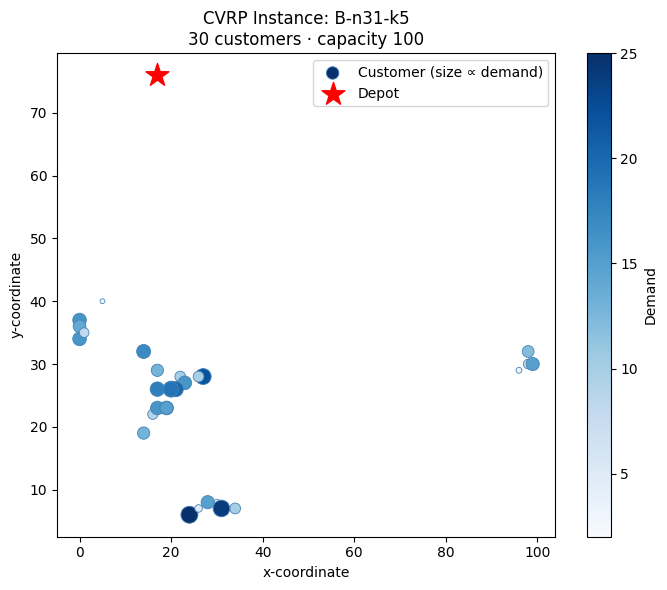

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

VIZ_INSTANCE = "B-n31-k5"
inst = instances[VIZ_INSTANCE]

coords  = np.array(inst["node_coord"])  # shape (n+1, 2)
demands = np.array(inst["demand"])

depot_xy    = coords[0]
customer_xy = coords[1:]
cust_dem    = demands[1:]

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    customer_xy[:, 0], customer_xy[:, 1],
    s=cust_dem * 6,       # marker area ∝ demand
    c=cust_dem,
    cmap="Blues",
    edgecolors="steelblue",
    linewidths=0.6,
    zorder=3,
    label="Customer (size ∝ demand)",
)
plt.colorbar(sc, ax=ax, label="Demand")

ax.scatter(depot_xy[0], depot_xy[1],
           marker="*", s=300, c="red", zorder=5, label="Depot")

ax.set_title(
    f"CVRP Instance: {VIZ_INSTANCE}\n"
    f"{len(customer_xy)} customers · capacity {inst['capacity']}",
    fontsize=12,
)
ax.set_xlabel("x-coordinate")
ax.set_ylabel("y-coordinate")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Running the Experiment

With the dataset loaded and inspected, we now run the **FunSearch + RAG** pipeline. The experiment follows this flow:

```
Dataset (CVRPLIB Set-B)
        │
        ▼
 FunSearch Core  ◄──── Island Population (evolutionary program database)
        │
        ├── Prompt construction (Chain-of-Thought template)
        │         │
        │         └── RAG Retriever ──► corpus/ (chunked VRP knowledge)
        │
        ├── LLM call  ──► generated Python heuristic
        │
        └── Evaluator ──► score (negative total distance)
                │
                └── best score updated in island population
```

The three cells below now handle:
1. **Imports** — loads FunSearch modules and in-notebook experiment logging helpers
2. **Configuration** — sets budget, model, seed, and RAG parameters
3. **Run** — executes `funsearch.main(...)`, writes `rag.txt` and `rag_summary.json` under `results/experiments/<timestamp>_<label>_rag/`


### Configuration

`VERIFICATION_BUDGET` controls how many LLM sampling steps FunSearch performs.  
Set it to `2` for a quick smoke-test, or `100` for a full experiment run.

| Parameter | Description |
|-----------|-------------|
| `VERIFICATION_BUDGET` | Maximum number of LLM samples (≈ API calls) |
| `MODEL_NAME` | OpenAI-compatible model identifier sent to the API |
| `RANDOM_SEED` | Global random seed for reproducibility |
| `rag_config` | RAG settings: corpus root, retrieval mode, top-k, context size, etc. |


In [ ]:
import contextlib
import dataclasses
from datetime import datetime
import json
from pathlib import Path
import sys
from zoneinfo import ZoneInfo

from implementation import funsearch
from implementation import sampler as sampler_lib
from scripts.compare_rag import parse_run_log


class TeeWriter:
    """Mirror stdout/stderr to both notebook output and a log file."""

    def __init__(self, *streams):
        self._streams = streams

    def write(self, data: str) -> int:
        for stream in self._streams:
            stream.write(data)
        return len(data)

    def flush(self) -> None:
        for stream in self._streams:
            stream.flush()


def make_timestamp() -> str:
    """
    Generate a timestamp string in the format 'yyyy-mm-dd_hh-mm' based on Beijing time.
    This format is suitable for use in filenames or folder names.
    """
    beijing_time = datetime.now(ZoneInfo("Asia/Shanghai"))
    return beijing_time.strftime("%Y-%m-%d_%H-%M")


print("Imports OK - FunSearch + RAG helpers loaded.")


Imports OK - FunSearch + RAG helpers loaded.


In [ ]:
VERIFICATION_BUDGET = 100   # increase to 100 for a full run
MODEL_NAME = "gpt-3.5-turbo"
RANDOM_SEED = 42

rag_config = config_lib.RAGConfig(
    enabled=True,
    corpus_root="corpus/",
    retrieval_mode="hybrid",
    top_k=2,
    score_threshold=0.0,
    max_context_chars=900,
    chunk_size=1200,
    chunk_overlap=200,
    enable_diagnostics=True,
    use_intent_query=False,
)

# Build base config then apply env-var overrides (picks up API key / base URL).
run_config = config_lib.apply_environment_overrides(
    config_lib.Config(
        samples_per_prompt=4,
        evaluate_timeout_seconds=30,
        llm_model=MODEL_NAME,
        model_track="rag",
        rag=rag_config,
        random_seed=RANDOM_SEED,
    )
)

print(f"Budget   : {VERIFICATION_BUDGET} samples")
print(f"Model    : {run_config.llm_model}")
print(f"Seed     : {run_config.random_seed}")
print(f"RAG      : enabled={run_config.rag.enabled} | mode={run_config.rag.retrieval_mode} | top_k={run_config.rag.top_k}")


Budget   : 100 samples
Model    : gpt-3.5-turbo
Seed     : 42
RAG      : enabled=True | mode=hybrid | top_k=2


In [ ]:
RESULTS_ROOT = Path("results")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

experiment_timestamp = make_timestamp()
experiment_dir = RESULTS_ROOT / f"{experiment_timestamp}_rag"
experiment_dir.mkdir(parents=True, exist_ok=True)
log_path = experiment_dir / "rag.txt"
summary_path = experiment_dir / "rag_summary.json"

print(f"Starting FunSearch + RAG experiment -> {experiment_dir}")

# NOTE: the `if __name__ == '__main__'` guard is required because the Sandbox
# uses multiprocessing - Colab's backend supports this correctly.
if __name__ == '__main__':
    class_config = config_lib.ClassConfig(
        llm_class=sampler_lib.LLM,
        sandbox_class=Sandbox,
    )

    with log_path.open("w", encoding="utf-8") as log_file:
        tee_stdout = TeeWriter(sys.__stdout__, log_file)
        tee_stderr = TeeWriter(sys.__stderr__, log_file)
        with contextlib.redirect_stdout(tee_stdout), contextlib.redirect_stderr(tee_stderr):
            print("================= EXPERIMENT START =================")
            print(f"RUN_MODE: {run_config.run_mode}")
            print(f"RUN_BUDGET: {VERIFICATION_BUDGET}")
            funsearch.main(
                specification=specification,
                inputs=cvrp_dataset,
                config=run_config,
                max_sample_nums=VERIFICATION_BUDGET,
                class_config=class_config,
                log_dir='../logs/funsearch_rag',
                dataset_path=DATASET_PATH,
            )
            print("================= EXPERIMENT END =================")

    parsed = parse_run_log(log_path)
    experiment_summary = {
        "timestamp": experiment_timestamp,
        "experiment_dir": str(experiment_dir.as_posix()),
        "summary_path": str(summary_path.as_posix()),
        "config": {
            "llm_model": run_config.llm_model,
            "seed": run_config.random_seed,
            "run_mode": run_config.run_mode,
            "budget": VERIFICATION_BUDGET,
            "rag_corpus_root": run_config.rag.corpus_root,
            "rag_retrieval_mode": run_config.rag.retrieval_mode,
            "rag_use_intent_query": run_config.rag.use_intent_query,
            "rag_top_k": run_config.rag.top_k,
            "rag_score_threshold": run_config.rag.score_threshold,
            "rag_max_context_chars": run_config.rag.max_context_chars,
            "rag_chunk_size": run_config.rag.chunk_size,
            "rag_chunk_overlap": run_config.rag.chunk_overlap,
        },
        "run": {
            "log_path": str(log_path.as_posix()),
            "best": parsed.best,
            "sample_lines": parsed.sample_lines,
            "valid_eval_ratio": parsed.valid_eval_ratio,
            "evals_per_sample": parsed.evals_per_sample,
            "retrieval_events": parsed.retrieval_events,
            "retrieval_mean_top_score": parsed.retrieval_mean_top_score,
            "retrieval_mean_top_score_gap": parsed.retrieval_mean_top_score_gap,
            "retrieval_mean_confidence": parsed.retrieval_mean_confidence,
            "retrieval_mean_injected_chars": parsed.retrieval_mean_injected_chars,
            "retrieval_mean_injected_sources": parsed.retrieval_mean_injected_sources,
            "retrieval_mean_unique_sources": parsed.retrieval_mean_unique_sources,
            "retrieval_multi_source_hit_rate": parsed.retrieval_multi_source_hit_rate,
            "retrieval_skip_ratio": parsed.retrieval_skip_ratio,
        },
    }

    summary_path.write_text(json.dumps(experiment_summary, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Experiment complete.")
    print(f"Summary JSON written to: {summary_path}")


Starting FunSearch + RAG experiment -> results/2026-04-26_18-25_rag


INFO:absl:Best score of island 0 increased to -1161.9876066089935
INFO:absl:Best score of island 1 increased to -1161.9876066089935
INFO:absl:Best score of island 2 increased to -1161.9876066089935
INFO:absl:Best score of island 3 increased to -1161.9876066089935
INFO:absl:Best score of island 4 increased to -1161.9876066089935
INFO:absl:Best score of island 5 increased to -1161.9876066089935
INFO:absl:Best score of island 6 increased to -1161.9876066089935
INFO:absl:Best score of island 7 increased to -1161.9876066089935
INFO:absl:Best score of island 8 increased to -1161.9876066089935
INFO:absl:Best score of island 9 increased to -1161.9876066089935
INFO:httpx:HTTP Request: POST https://api.chatanywhere.com.cn/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.chatanywhere.com.cn/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.chatanywhere.com.cn/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://ap

Experiment complete.
Summary JSON written to: results/2026-04-26_18-25_rag/rag_summary.json


### Results

After the run completes, this notebook restores the same structured outputs as before:

- `results/experiments/<timestamp>_<label>_rag/rag.txt` — raw run log
- `results/experiments/<timestamp>_<label>_rag/rag_summary.json` — structured summary
- in-memory `experiment_summary` — Python dict for immediate inspection

The cell below prints the key metrics and the full summary object.


In [ ]:
print("-" * 50)
print(f"Output directory  : {experiment_summary['experiment_dir']}")
print(f"Summary JSON      : {experiment_summary['summary_path']}")
print(f"Raw log           : {experiment_summary['run']['log_path']}")
print("-" * 50)
print(f"best_score               : {experiment_summary['run']['best']}")
print(f"valid_eval_ratio         : {experiment_summary['run']['valid_eval_ratio']}")
print(f"retrieval_events         : {experiment_summary['run']['retrieval_events']}")
print(f"retrieval_mean_confidence: {experiment_summary['run']['retrieval_mean_confidence']}")
print("-" * 50)
print(json.dumps(experiment_summary, indent=2, ensure_ascii=False))


--------------------------------------------------
Output directory  : results/2026-04-26_18-25_rag
Summary JSON      : results/2026-04-26_18-25_rag/rag_summary.json
Raw log           : results/2026-04-26_18-25_rag/rag.txt
--------------------------------------------------
best_score               : None
valid_eval_ratio         : 0.900990099009901
retrieval_events         : 25
retrieval_mean_confidence: 0.46241467999999997
--------------------------------------------------
{
  "timestamp": "2026-04-26_18-25",
  "experiment_dir": "results/2026-04-26_18-25_rag",
  "summary_path": "results/2026-04-26_18-25_rag/rag_summary.json",
  "config": {
    "llm_model": "gpt-3.5-turbo",
    "seed": 42,
    "run_mode": "full",
    "budget": 100,
    "rag_corpus_root": "corpus/",
    "rag_retrieval_mode": "hybrid",
    "rag_use_intent_query": false,
    "rag_top_k": 2,
    "rag_score_threshold": 0.0,
    "rag_max_context_chars": 900,
    "rag_chunk_size": 1200,
    "rag_chunk_overlap": 200
  },
  "ru

## Conclusion

In this notebook we demonstrated a complete end-to-end run of **FunSearch augmented with Retrieval-Augmented Generation (RAG)** on the **Capacitated Vehicle Routing Problem (CVRP)**, while keeping the key runtime pieces directly in the notebook.

### What we did

| Step | Description |
|------|-------------|
| **1. Setup** | Cloned and pinned the repository branch in a fresh Colab runtime |
| **2. Dependencies** | Installed minimal runtime dependencies (`vrplib`, `numpy`, `openai`) |
| **3. In-notebook runtime blocks** | Kept the **Sandbox**, **specification**, **dataset loader**, and **run entry** in notebook cells |
| **4. Experiment run** | Executed `funsearch.main(...)` with RAG-enabled config (`rag_config`) and multiprocessing-safe guard |
| **5. Structured outputs** | Persisted `rag.txt` and `rag_summary.json`, and exposed `experiment_summary` for immediate inspection |

### Key takeaways

- **RAG improves prompt grounding**: retrieved corpus chunks provide context before each LLM mutation call.
- **FunSearch remains sample-efficient**: island-based evolutionary search maintains diversity and helps avoid local optima.
- **Notebook reproducibility is preserved**: each run writes a timestamped experiment directory with both raw and structured artifacts.
